In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jarvisgroot/brain-tumor-classification-mri-images")

print("Path to dataset files:", path)


Path to dataset files: C:\Users\Bheemendra\.cache\kagglehub\datasets\jarvisgroot\brain-tumor-classification-mri-images\versions\1


In [3]:
import os

print(os.listdir(path))

['brain_tumor_mri', 'test_images-20210704T210303Z-001']


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
data_dir = os.path.join(path, "brain_tumor_mri")
print(os.listdir(data_dir))

['new_dataset']


In [6]:
small_dataset_dir = "brain_tumor_mri_3k_dataset"
os.makedirs(small_dataset_dir, exist_ok=True)

In [7]:
import shutil
import random

classes = os.listdir(data_dir)

images_per_class = 100   # adjust based on total classes

for cls in classes:
    class_path = os.path.join(data_dir, cls)
    new_class_path = os.path.join(small_dataset_dir, cls)

    os.makedirs(new_class_path, exist_ok=True)

    images = os.listdir(class_path)
    selected_images = random.sample(images, min(images_per_class, len(images)))

    for img in selected_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(new_class_path, img)
        # Check if the source is a directory or a file
        if os.path.isdir(src):
            # If it's a directory, use shutil.copytree
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            # If it's a file, use shutil.copyfile
            shutil.copyfile(src, dst)

print("3K dataset created successfully!")

3K dataset created successfully!


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
data_dir = "brain_tumor_mri_3k_dataset"

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [12]:
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

valid_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 2452 images belonging to 1 classes.
Found 612 images belonging to 1 classes.


In [13]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [15]:
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


In [16]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=5
)

Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 253s 3s/step - accuracy: 0.9959 - loss: 0.0090 - val_accuracy: 1.0000 - val_loss: 1.3548e-07
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 1.0000 - loss: 1.2488e-06 - val_accuracy: 1.0000 - val_loss: 5.5677e-08
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 194s 3s/step - accuracy: 1.0000 - loss: 9.4155e-07 - val_accuracy: 1.0000 - val_loss: 2.6300e-08
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 1.0000 - loss: 9.7117e-07 - val_accuracy: 1.0000 - val_loss: 1.6809e-08
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 1.0000 - loss: 7.9603e-07 - val_accuracy: 1.0000 - val_loss: 1.0963e-08


In [18]:
base_model.trainable = True

In [19]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [20]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_fine = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 300s 3s/step - accuracy: 1.0000 - loss: 7.3076e-06 - val_accuracy: 1.0000 - val_loss: 3.1580e-07
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 261s 3s/step - accuracy: 1.0000 - loss: 1.0229e-06 - val_accuracy: 1.0000 - val_loss: 2.4379e-06
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 229s 3s/step - accuracy: 1.0000 - loss: 4.1897e-07 - val_accuracy: 1.0000 - val_loss: 7.7245e-07
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 236s 3s/step - accuracy: 1.0000 - loss: 3.3166e-07 - val_accuracy: 1.0000 - val_loss: 1.2358e-07
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 237s 3s/step - accuracy: 1.0000 - loss: 2.9921e-07 - val_accuracy: 1.0000 - val_loss: 2.4135e-08
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 236s 3s/step - accuracy: 1.0000 - loss: 1.6147e-07 - val_accuracy: 1.0000 - val_loss: 1.0425e-08
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 1.0000 - loss: 1.5029e-07 - val_accuracy: 1.0000 - val_loss: 5.6407e-09
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 233s 3s/step - ac

In [22]:
loss, accuracy = model.evaluate(valid_generator)
print("Validation Accuracy:", accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 1.0000 - loss: 1.5922e-09
Validation Accuracy: 1.0


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


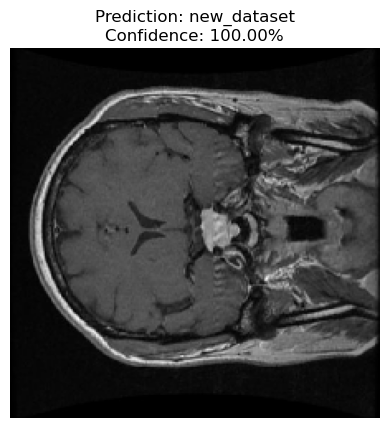

Predicted Class: new_dataset
Confidence: 100.0 %


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Provide test image path 
img_path = ("1146.jpg")
# Load and preprocess image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Make prediction 
predictions = model.predict(img_array)

# Get class names
class_indices = train_generator.class_indices
class_names = list(class_indices.keys())

predicted_class = class_names[np.argmax(predictions)]
confidence = np.max(predictions)


plt.imshow(img)
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence*100:.2f}%")
plt.axis("off")
plt.show()

print("Predicted Class:", predicted_class)
print("Confidence:", confidence*100, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


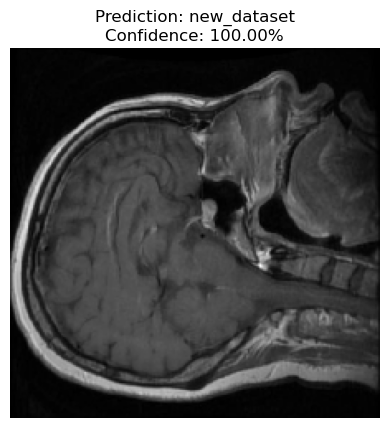

Predicted Class: new_dataset
Confidence: 100.0 %


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Provide test image path 
img_path = ("1227.jpg")
# Load and preprocess image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Make prediction 
predictions = model.predict(img_array)

# Get class names
class_indices = train_generator.class_indices
class_names = list(class_indices.keys())

predicted_class = class_names[np.argmax(predictions)]
confidence = np.max(predictions)


plt.imshow(img)
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence*100:.2f}%")
plt.axis("off")
plt.show()

print("Predicted Class:", predicted_class)
print("Confidence:", confidence*100, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


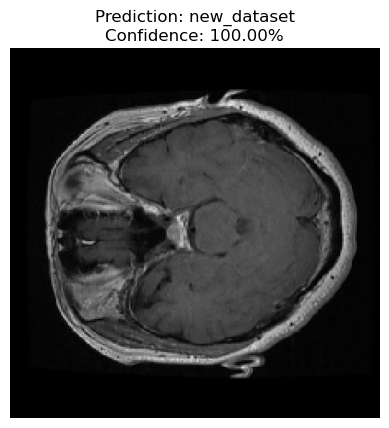

Predicted Class: new_dataset
Confidence: 100.0 %


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Provide test image path 
img_path = ("1348.jpg")
# Load and preprocess image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Make prediction 
predictions = model.predict(img_array)

# Get class names
class_indices = train_generator.class_indices
class_names = list(class_indices.keys())

predicted_class = class_names[np.argmax(predictions)]
confidence = np.max(predictions)


plt.imshow(img)
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence*100:.2f}%")
plt.axis("off")
plt.show()

print("Predicted Class:", predicted_class)
print("Confidence:", confidence*100, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


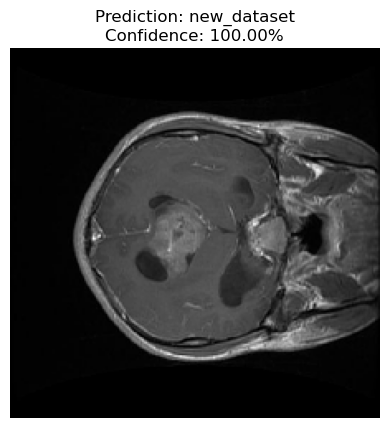

Predicted Class: new_dataset
Confidence: 100.0 %


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Provide test image path 
img_path = ("2561.jpg")
# Load and preprocess image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Make prediction 
predictions = model.predict(img_array)

# Get class names
class_indices = train_generator.class_indices
class_names = list(class_indices.keys())

predicted_class = class_names[np.argmax(predictions)]
confidence = np.max(predictions)


plt.imshow(img)
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence*100:.2f}%")
plt.axis("off")
plt.show()

print("Predicted Class:", predicted_class)
print("Confidence:", confidence*100, "%")